In [1]:
from sys import path as spth
from os import (chdir,getcwd)
chdir(getcwd())
from os import path as os_path
from importlib import reload
import numpy as np
from time import strftime
from timeit import default_timer as de_time
from h5py import File as h5_file
from glob import glob as globf
import matplotlib.pyplot as plt

%matplotlib widget
###############################################
from databroker import Broker
db = Broker.named('six')
sample = None
#################################################################
from Loc_Funcs import (six_data,print_data,scan_info,load_centroids_data_frame)
import six_plot as splt 
reload(splt)
#################################################################
E_cali_O = 13.96 # meV/pixel at O K-edge
E_cali_Mn = 18.83 # meV/pixel at Mn L-edge
E_cali_Fe = 21.65 # meV/pixel at Fe L-edge

# Motor Scan Plot

It is loading the scan: six-315086


Output()



It takes 14.997448990121484 seconds to load all these scans!


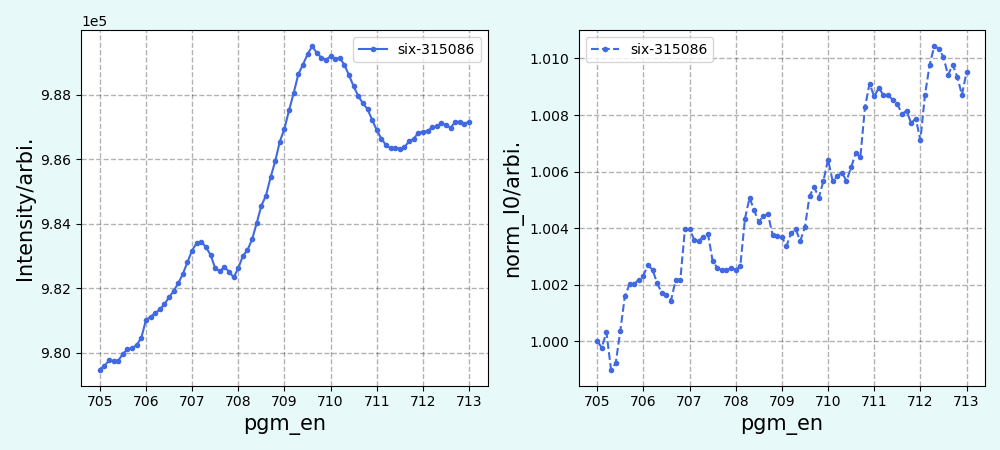

In [2]:
scan = np.array([315086])

######################################################
sample=sample # sample name
######################################################
start_time = de_time()
splt.scan_plot(scan,plt_close=0,sample=sample)
##############################################################################################
end_time = de_time()
print('\n')
print('It takes {} seconds to load all these scans!'.format((end_time - start_time)))
fig = plt.gcf()
fig.tight_layout()

# Load all RIXS data into working space

In [2]:
scan_set = np.hstack([np.arange(333977,333977+1,1)]) 

print(scan_set)
#############################################################################################################
E_cali = E_cali_Fe
#############################################################################################################
start_time = de_time()
raw_data = six_data(scan_set,E_cali=E_cali)
##############################################################################################
print_data(raw_data,scan=scan_set)
print('***************************************************************************************************************')
print('All scans have been loaded into the working space!')
end_time = de_time()
print('\n')
print('It takes {:.2f} seconds to load these scans!'.format((end_time - start_time)))

[333977]
Caught exception: OSError('Unable to synchronously open file (file signature not found)')
Path: /nsls2/data/six/proposals/2026-1/pass-319986/assets/rixscam/2026/04/04/c63b51b0-3651-4f27-836a_000059.h5
Index: 59
Filling in `0` values for this frame!
Caught exception: OSError('Unable to synchronously open file (file signature not found)')
Path: /nsls2/data/six/proposals/2026-1/pass-319986/assets/rixscam/2026/04/04/c63b51b0-3651-4f27-836a_000060.h5
Index: 60
Filling in `0` values for this frame!
--- six-333977 --- points 118 --- split time 5.0s --- total 590.0s --- duration 724.2s --- when Sat Apr  4 18:58:49 2026
+-----------+-------------+------------------+--------------------+----------------------+----------------+-----------+
| Scan Num. | Theta (deg) | Inc. Energy (eV) |    2Theta (deg)    | Polarization (phase) | Exit Slit (um) | Temp. (K) |
+-----------+-------------+------------------+--------------------+----------------------+----------------+-----------+
|   333977  

# Browse raw data

Output()

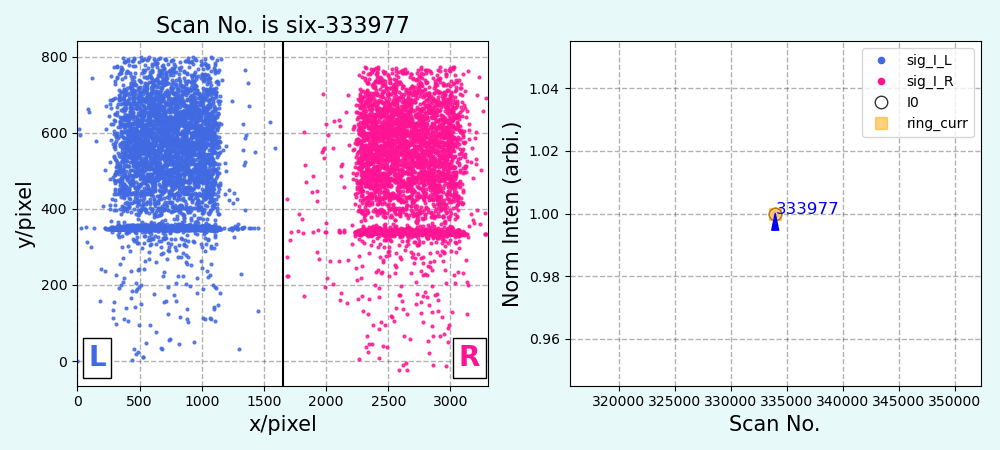

In [3]:
scan_rixs = scan_set
######################################################################################
sig_roi=[] # Array with up to 4 elements :[left_edge for left sensor,right_edge for left sensor,
                   # let_edge for right sensor,right_edge for right sensor], the region of interest for signal.
######################################################################################
data = splt.raw_sig(raw_data,*tuple(sig_roi),scan=scan_rixs,plt_close=1) 
fig = plt.gcf()
fig.tight_layout()

# Check slope for pseudo-2D signal

Output()

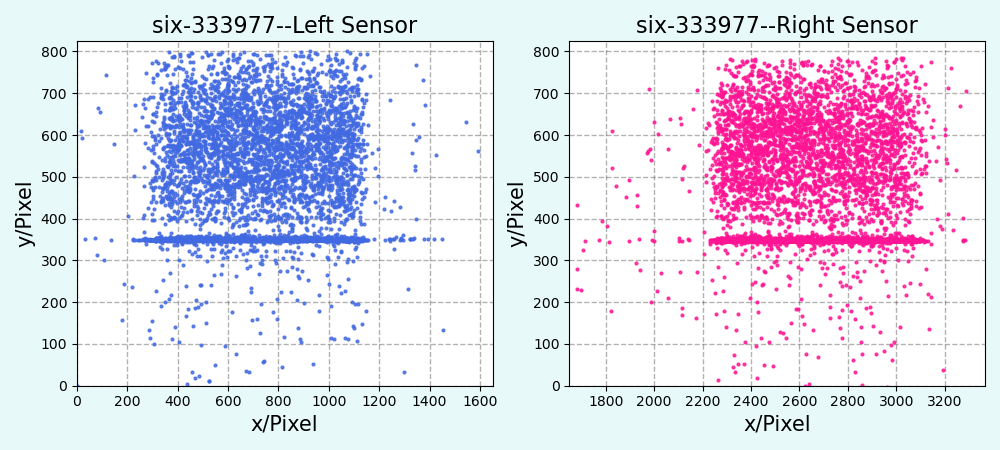

In [4]:
slope_l=-0.0012
slope_r=-0.0040

########################################################################
slope_dict=splt.check_slope(data,scan=scan_rixs,
                            slope_l=slope_l,slope_r=slope_r,
                            plt_close=1)
fig = plt.gcf()
fig.tight_layout()

# Handle the statistics and resolution ---> points_per_pixel

-0.0012000000000000283 -0.003999999999999979


Output()

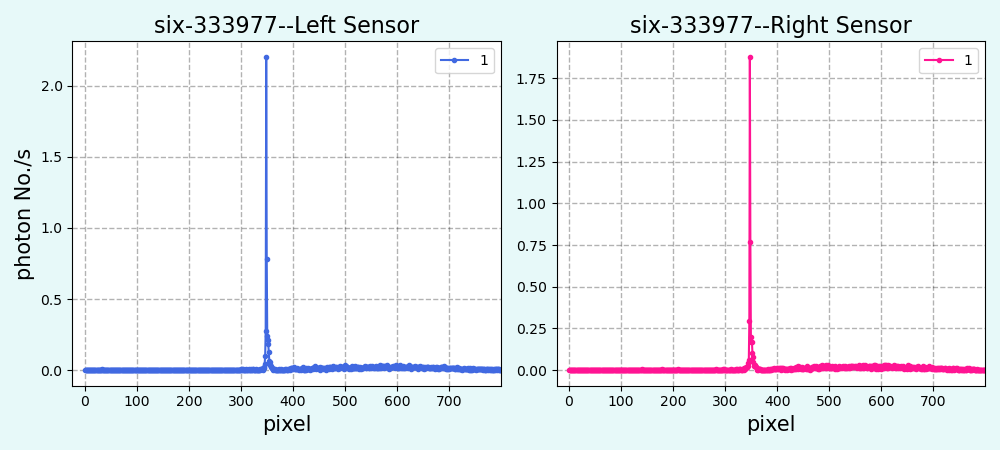

In [5]:
slope_l = slope_dict['slope_l'].get_interact_value()
slope_r = slope_dict['slope_r'].get_interact_value()

print(slope_l,slope_r)

stat_dict = splt.stat_plot(data,scan=scan_rixs,
                           slope_l=slope_l,slope_r=slope_r,
                           plt_close=1)
fig = plt.gcf()
fig.tight_layout()

# Check the correlation between different scans

Output()

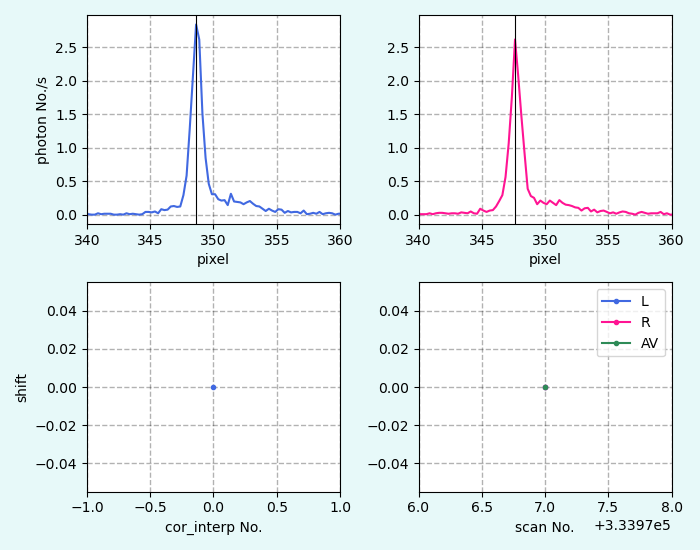

In [7]:
slope_l = slope_dict['slope_l'].get_interact_value()
slope_r = slope_dict['slope_r'].get_interact_value()
points_per_pixel_cor = stat_dict['points_per_pixel_cor'].get_interact_value()

####################################
center, window = 350, 10 
cor_roi = np.array([[center-window,center+window],[center-window,center+window]]) 

########################################################################
cor_dict = splt.check_cor(data,scan=scan_rixs,
                slope_l=slope_l,slope_r=slope_r,points_per_pixel=points_per_pixel_cor,
                 cor_roi = cor_roi,
                plt_close=1)
########################################################################
fig = plt.gcf()
fig.tight_layout()

# Check spectra after correlated shifts

self


Output()

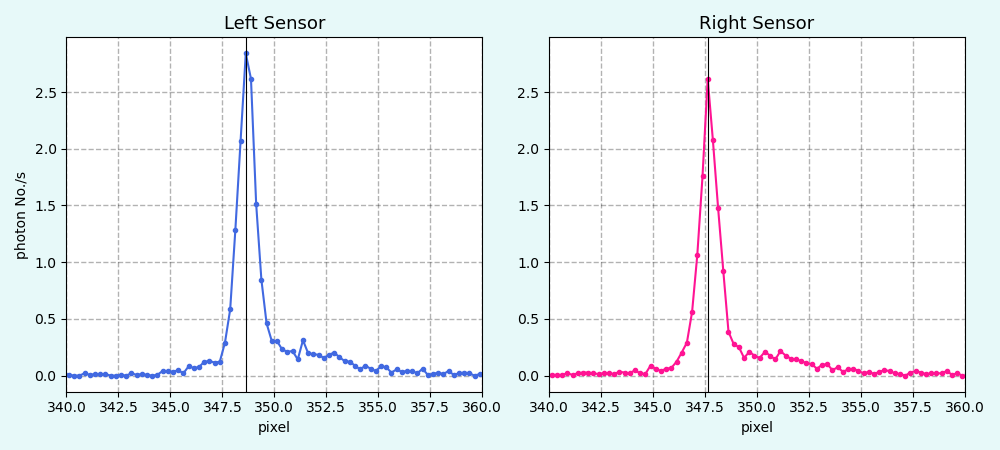

In [8]:
slope_l = slope_dict['slope_l'].get_interact_value()
slope_r = slope_dict['slope_r'].get_interact_value()
points_per_pixel = stat_dict['points_per_pixel_cor'].get_interact_value()
####################################################################################"
cor_roi_l = [cor_dict['xlow_l'].get_interact_value(),cor_dict['xhigh_l'].get_interact_value()]
cor_roi_r = [cor_dict['xlow_r'].get_interact_value(),cor_dict['xhigh_r'].get_interact_value()]
cor_interp=cor_dict['cor_interp'].get_interact_value()
shift_type=cor_dict['shift_type'].get_interact_value()
print(shift_type)
########################################################################
splt.check_spec_shift(data, scan=scan_rixs,
                    slope_l=slope_l, slope_r=slope_r, points_per_pixel=points_per_pixel,
                    cor_roi_l=cor_roi_l,cor_roi_r=cor_roi_r,cor_interp=cor_interp,shift_type=shift_type,
                    plt_close=1)
##############################################
fig = plt.gcf()
fig.tight_layout()

# Perform correlation between different sensors (left and right) leading to the sum and save data!

self


Output()

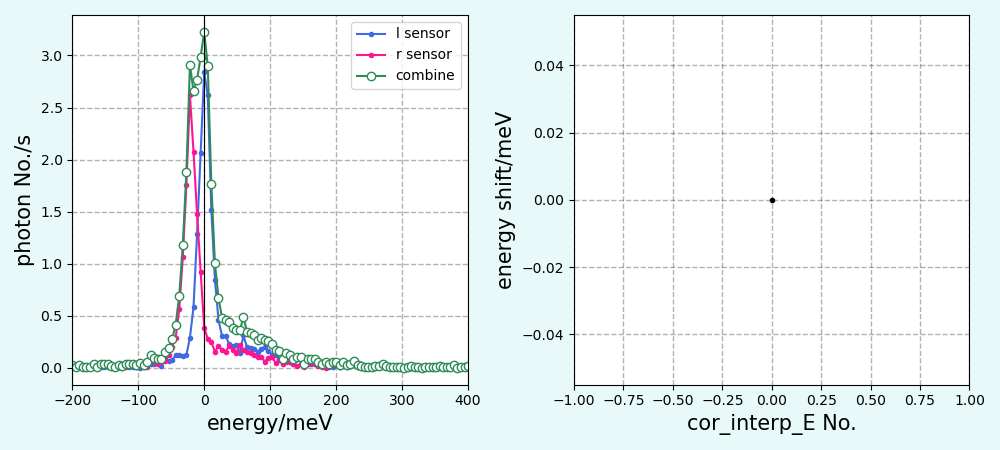

In [9]:
slope_l = slope_dict['slope_l'].get_interact_value()
slope_r = slope_dict['slope_r'].get_interact_value()
points_per_pixel = stat_dict['points_per_pixel_cor'].get_interact_value()

####################################################################################
cor_roi_l = [cor_dict['xlow_l'].get_interact_value(),cor_dict['xhigh_l'].get_interact_value()]
cor_roi_r = [cor_dict['xlow_r'].get_interact_value(),cor_dict['xhigh_r'].get_interact_value()]
cor_interp=cor_dict['cor_interp'].get_interact_value()
shift_type=cor_dict['shift_type'].get_interact_value()
print(shift_type)
########################################################################
splt.spec_cor(data, scan=scan_rixs,sample=sample,
              slope_l=slope_l, slope_r=slope_r, points_per_pixel=points_per_pixel,
              cor_roi_l=cor_roi_l,cor_roi_r=cor_roi_r,cor_interp=cor_interp,
              shift_type=shift_type,
              plt_close=1)
##############################################
fig = plt.gcf()
fig.tight_layout()

# Display RIXS Spectra

Output()

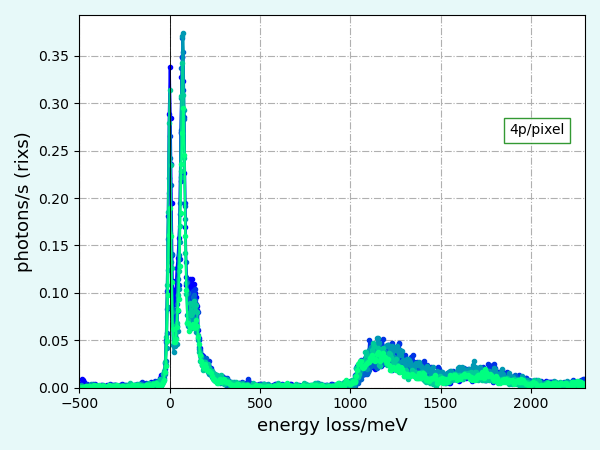

In [459]:
points_per_pixel = 4
data_folder =getcwd()+'/Data/points_per_pixel-'+str(points_per_pixel)+'/'
######################################################

scan = np.array([333481,333487,333494,333500,333511,333521])

data_type = 'hdf' # it can be 'hdf' or 'txt'
#############################################################################################################
# plt.close()
# fig = plt.figure('Display RIXS Map', figsize=(3, 7))
splt.rixs1d(data_folder=data_folder,scan=scan,data_type=data_type,sample=sample,fig=None,plt_close=1)
fig = plt.gcf()
fig.tight_layout()

# Display RIXS Map --> Only work for .hdf files

/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326187_326188.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326189_326190.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326191_326192.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326193_326194.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326195_326196.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326197_326198.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326199_326200.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326201_326202.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-326203_326204.hdf
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/si

Output()

/tmp/ipykernel_3095836/2280569146.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


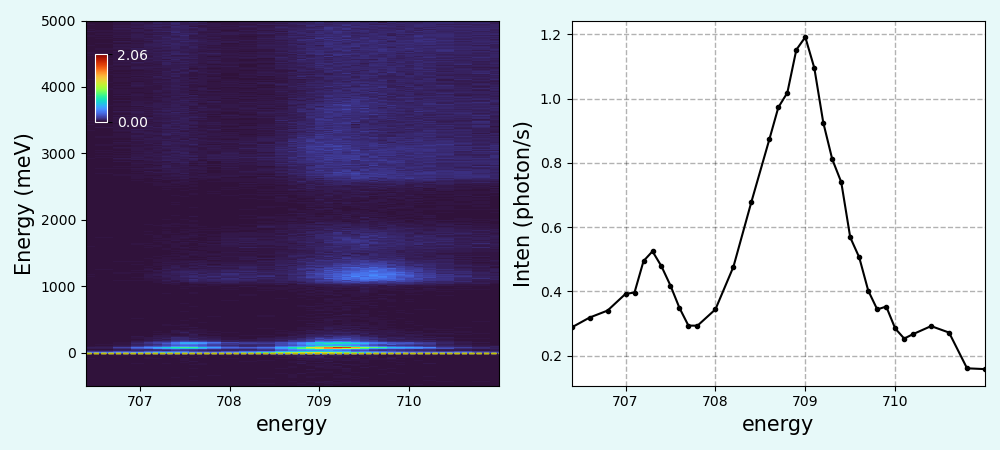

In [270]:
points_per_pixel = 4
data_folder =getcwd()+'/Data/points_per_pixel-'+str(points_per_pixel)+'/RawData/'
######################################################
scan = np.arange(326187,326257+1,1)

#########################################
vari = 'energy' # This parameter can be 'energy' (incident photon energy) or 'th'.
vari_offset = 0 # The potential offset for vari
cut_type = 'H' # There are two choices: 'H' or 'V' !!!
#############################################################################################################
# plt.close('all')
# fig = plt.figure('Display RIXS Map', figsize=(8, 6.))
splt.rixs2d(data_folder=data_folder,scan=scan,sample=sample,
            vari=vari,vari_offset = vari_offset,cut_type=cut_type,
            colormap='turbo',fig=None,plt_close=1)
fig = plt.gcf()
fig.tight_layout()

# Print data information --> Only work for .hdf files

In [308]:
points_per_pixel = 2.5
data_folder =getcwd()+'/Data/points_per_pixel-'+str(points_per_pixel)+'/RawData/'
######################################################
scan = np.arange(141861,141864+1,1) # E-dep at T=300K & LH

#############################################################
disp = ['x','y'] # The element can be any items in the meta of .hdf file.
#############################################################################################################
scan_info(data_folder,scan=scan,sample=sample,disp=disp)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-2.5/RawData/six-141861.hdf', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# Extract the meta-data --> Only work for .hdf files

In [ ]:
points_per_pixel = 2.5
data_folder =getcwd()+'/Data/points_per_pixel-'+str(points_per_pixel)+'/RawData/'
######################################################
scan = np.arange(141861,141864+1,1) # E-dep at T=300K & LH


#########################################
meta='th' # It must be specified and one numerical item in the meta of .hdf file.
#############################################################################################################
# plt.close('all')
# fig = plt.figure('Display RIXS Map', figsize=(7, 4.5))
splt.meta_plot(data_folder=data_folder,scan=scan,sample=sample,
                meta=meta,fig=None,plt_close=1)
fig = plt.gcf()
fig.tight_layout()

# Self-plot --> XAS

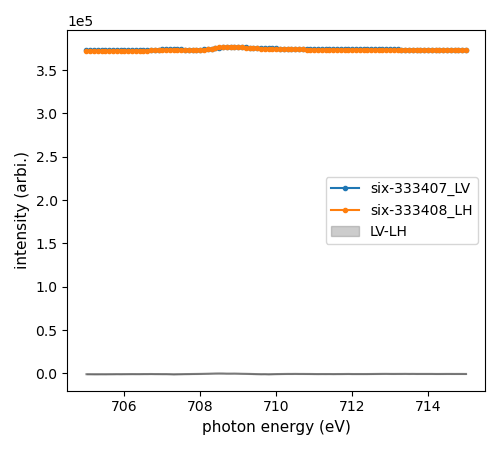

In [7]:
data_folder = getcwd()+'/Data/'
#################################################################

scan = np.array([333407,333408]) # sclr
labels = ['LV','LH']
xshift = [0,0]
yshift = [0,0]

rescale=0 # 1 for rescaling if needed

sig = 'sclr_channels_chan2' # TFY signal
# sig = 'sclr_channels_chan6'  # TEY signal
# sig = 'rixscam'  # RIXSCAM signal
#################################################################

colors = ['C'+str(i) for i in range(len(scan))]
#################################################################3
plt.close('all')
fig = plt.figure(strftime("%Y %b %d  %H:%M:%S"),figsize=(5.,4.5))
ax = fig.add_subplot(111)
#################################################################
for i,n in enumerate(scan):
    if sample is None:
        sample='six'
    data = h5_file(data_folder + sample+'-' + str(int(n))+'.hdf','r')
    vari = [k for k in data['data'].keys() if k[:4] not in ['sclr','rixs','ring']]
    #################################################################
    # I = data['data'][sig][:,0]
    I = data['data'][sig][:,0]
    E = data['data'][vari[0]][:,0]
    #################################################################
    if rescale==1:
        I-=(np.mean(I[:5])) # background subtraction
        # I/=(np.mean(I[-2:])) # Normalized by the flat region at the end
        # I/=I.max() # Normalized by maximum intensity
    else:
        pass
    
    if i==0:
        I_ref = I
        E_ref = E
        
    ax.plot(E+xshift[i],I+yshift[i],marker='.',linestyle='-',color=colors[i],label='six-'+str(n)+'_'+labels[i])

    # if i==1:
    #     ax.plot(E,(I-I_ref),linestyle='-',color='k',alpha=0.4)
    #     ax.fill_between(E,0,(I-I_ref),color='grey',alpha=0.4,label='LV-LH')

ax.set_xlabel('photon energy (eV)',fontdict={'fontsize':11})
ax.set_ylabel('intensity (arbi.)',fontdict={'fontsize':11})
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))    
ax.legend()
fig.tight_layout()

# Self-plot --> RIXS spectra

/nsls2/users/tkim3/Analysis_Codes/ver_May_21_2026/Data/points_per_pixel-4/six-337116_337121.hdf
16.0002743995
/nsls2/users/tkim3/Analysis_Codes/ver_May_21_2026/Data/points_per_pixel-4/six-337122_337127.hdf
16.000311950300002
/nsls2/users/tkim3/Analysis_Codes/ver_May_21_2026/Data/points_per_pixel-4/six-337196_337201.hdf
73.00002444020001
/nsls2/users/tkim3/Analysis_Codes/ver_May_21_2026/Data/points_per_pixel-4/six-337202_337207.hdf
73.000115635
/nsls2/users/tkim3/Analysis_Codes/ver_May_21_2026/Data/points_per_pixel-4/six-337238_337246.hdf
136.0000355883
/nsls2/users/tkim3/Analysis_Codes/ver_May_21_2026/Data/points_per_pixel-4/six-337247_337251.hdf
136.0000342472


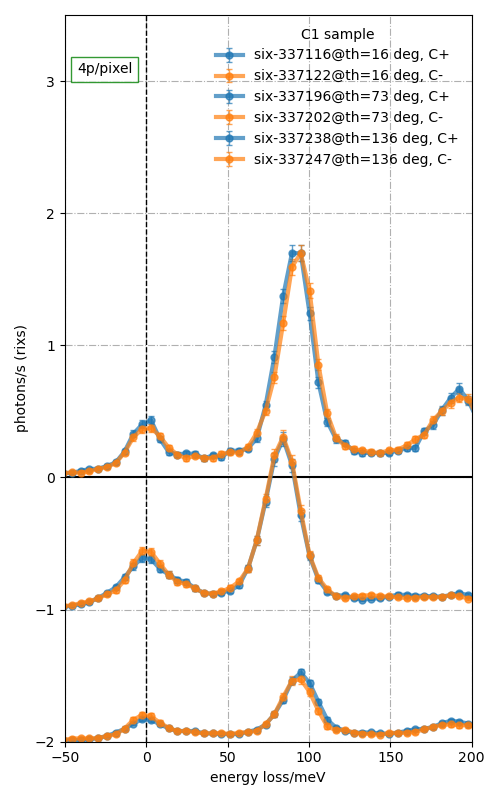

In [100]:
points_per_pixel = 4
data_folder =getcwd()+'/Data/points_per_pixel-'+str(points_per_pixel)+'/'
######################################################

scan = [337116,337122,337196,337202,337238,337247]
labels = ['th=16 deg, C+','th=16 deg, C-','th=73 deg, C+','th=73 deg, C-','th=136 deg, C+','th=136 deg, C-']
xshift=[0,0,0,0,0,0,0]
yshift=[0,0,0,0,0,0,0]
title = 'C1 sample'
mycolors = ['C0','C1','C0','C1','C0','C1']

#################################################################
sig = 'rixs' # 'rixs_l' for left and 'rixs_r' for right detectors
vari='th'

norm = 0
norm_range = [40,100] # meV, energy range for normalization
#################################################################
colors = ['royalblue','deeppink','brown','seagreen','darkviolet','olive']
#################################################################
if sig == 'rixs':
    sig_x = 'E'
    sig_path = 'comb'
elif sig == 'rixs_l':
    sig_x = 'E_l'
    sig_path = 'left'
elif sig == 'rixs_r':
    sig_x = 'E_r'
    sig_path = 'right'
#################################################################       
plt.close('all')
if points_per_pixel>1:
    fig = plt.figure(strftime("%Y %b %d  %H:%M:%S"),figsize=(5,8))
else:
    fig = plt.figure(strftime("%Y %b %d  %H:%M:%S"),figsize=(8,4.5))
ax = fig.add_subplot(111)
#################################################################
for i,n in enumerate(scan):
    if sample is None:
        sample='six'
    ####################################################################
    list_of_files = globf(data_folder + sample+'-' + str(n) + '*.hdf')
    latest_file = max(list_of_files, key=os_path.getctime)
    data_file = h5_file(latest_file, 'r')
    print(latest_file)
    count_time = np.sum(data_file['meta']['count_time'][:,0])
    vari_data = data_file['meta'][vari][0,0]
    print(vari_data)
    ####################################################################
    if len(list(data_file.keys())) == 3:
        if sig_path == 'comb':
            x = data_file['data']['E'][:, 0]+xshift[i]
            y = data_file['data']['rixs'][:, 0]
        else:
            x = data_file['data'][sig_path]['E'][:, 0]+xshift[i]
            y = data_file['data'][sig_path]['rixs'][:, 0]

    elif len(list(data_file.keys())) == 2:
        x = data_file['data'][sig_x][:, 0]+xshift[i]
        y = data_file['data'][sig][:, 0]
    else:
        print('Data structure is wrong, please process the data again!!!')
                    
    ##############################################################################
    if i==0:
        x_ref = x
        if norm==1:
            y_ref = y/np.sum(y[(x_ref>=norm_range[0])&(x_ref<=norm_range[1])])
        else:
            y_ref = y
    y_interp = np.interp(x_ref,x,y)
    y_interp_error = np.sqrt(y_interp / points_per_pixel * count_time)*points_per_pixel/count_time
    ##########################################
    if norm==1:
        norm_f = np.sum(y_interp[(x_ref>=norm_range[0])&(x_ref<=norm_range[1])])
    else:
        norm_f = 1
    ##########################################
    y_interp_norm = y_interp/norm_f
    y_interp_error_norm = y_interp_error/norm_f
    ##########################################
    ax.errorbar(x_ref,y_interp_norm+yshift[i],yerr=y_interp_error_norm,
                 marker='o',mfc=mycolors[i],mec=mycolors[i],ecolor=mycolors[i],markersize=5,markeredgewidth=1,
                 linestyle='-',color=mycolors[i],lw=3.0,alpha=0.7,elinewidth=1,capsize=2.,
                label='six-{:.0f}'.format(n)+'@'+labels[i])
    # if i==1:
    #     ax.plot(x_ref,(y_interp_norm-y_ref),linestyle='-',lw=0.8,color='orange',alpha=0.6)
    #     ax.fill_between(x_ref,0,(y_interp_norm - y_ref),color='orange',alpha=0.4,label='diff')

if points_per_pixel>1:
    ax.set_xlim(-50, 200)
else:
    ax.set_xlim(500,10000)
ax.axvline(0,linestyle='--',color='k',linewidth=1)
ax.axhline(0,linestyle='-',color='k')
#################################################################
ax.set_xlabel('energy loss/meV')
ax.set_ylim(yshift[-1],3.5)
if norm == 0:
    ax.set_ylabel('photons/s ('+sig+')')
else:
    ax.set_ylabel('normalized intensity/arbi. ('+sig+')')
#################################################################
ax.grid(linestyle='-.')

ax.text(.03, .92, str(points_per_pixel)+'p/pixel', transform=ax.transAxes,# ha="left", va="center",
       bbox=dict(edgecolor='green', facecolor='w',alpha=0.8))  
#################################################################
ax.legend(title=title,frameon=False)
fig.tight_layout()

/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315331_315336.hdf
4.000099529600007
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315337_315342.hdf
4.000151832500009
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-333547_333549.hdf
4.000120987200006
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-333558_333562.hdf
4.000094165199997
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-333566_333569.hdf
9.999993175599997
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-333570_333573.hdf
9.999990493400006
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-0.5/six-315331_315336.hdf
4.000099529600007
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-0.5/six-315337_315342.hdf
4.000151832500009
/nsls2/data2/six/proposals/2023-1/pa

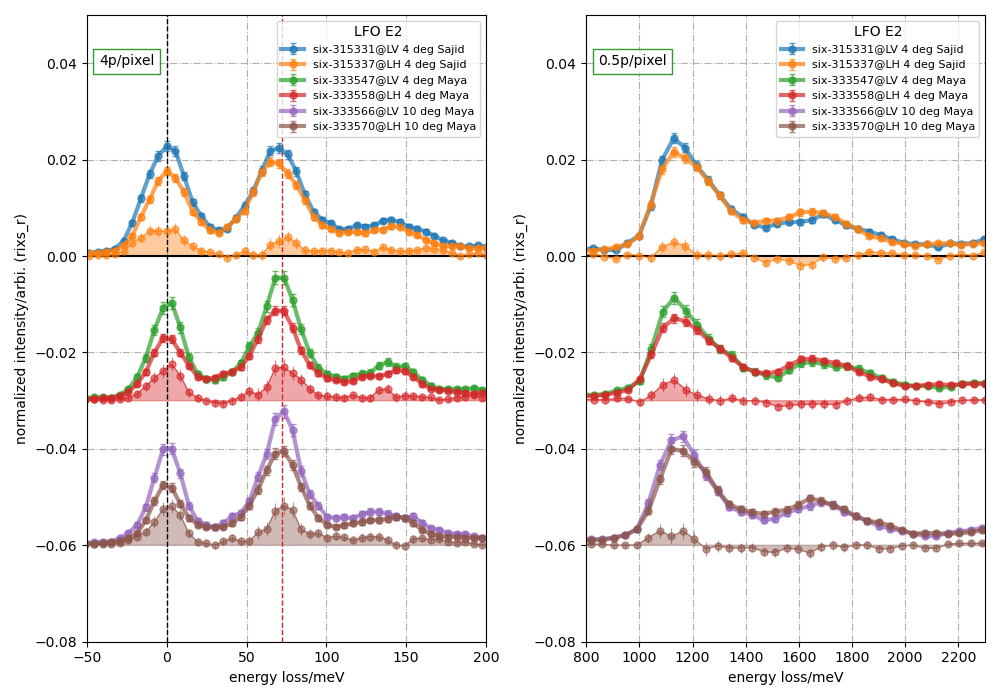

In [672]:
ppp = [4, 0.5]

######################################################
# # comparison at fixed energy
# scan = [314993,314999,315199,315205,315213,315219]
# labels = ['BFO/LFO, LV','BFO/LFO, LH','LFO, LV','LFO, LH','BFO, LV','BFO, LH']
# title = 'th=20 deg, E=709.5 eV'
# xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
# yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
# yshifts=[[0,0,-1.0,-1.0,-2.0,-2.0],[0,0,-0.1,-0.1,-0.2,-0.2]]

# comparison at fixed energy
scan = [326282,326477,333436,333442] # LBLFO
labels = ['LV 20 deg','LH 20 deg','LV 125 deg','LH 125 deg']
title = 'E1=709.05-0.3 eV'
xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
yshifts=[[0,0,-1.0,-1.0],[0,0,-0.1,-0.1]]
# yshifts=[[0,0,-0.03,-0.03],[0,0,-0.03,-0.03]]

# comparison between E1 and E2
scan = [333436,333442,333449,333455] # LBLFO
labels = ['LV E1','LH E1','LV E2','LH E2']
title = 'th=125 deg'
# xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
xshifts=[[0,0,0,-2],[0,0,0,-2]]
yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
yshifts=[[0,0,-1.0,-1.0],[0,0,-0.1,-0.1]]
# yshifts=[[0,0,-0.03,-0.03],[0,0,-0.03,-0.03]]

# BFO comparison
scan = [315213,315219,333464,333470] # BFO
labels = ['LV 20 deg','LH 20 deg','LV 125 deg','LH 125 deg']
title = 'BFO'
# xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
xshifts=[[0,0,0,0],[0,0,0,0]]
yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
yshifts=[[0,0,-1.0,-1.0],[0,0,-0.1,-0.1]]
# yshifts=[[0,0,-0.03,-0.03],[0,0,-0.03,-0.03]]

# BLFO comparison
scan = [314993,314999,333481,333487] # BFO
labels = ['LV 20 deg','LH 20 deg','LV 125 deg','LH 125 deg']
title = 'BLFO E1'
# xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
xshifts=[[0,0,0,0],[0,0,0,0]]
yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
yshifts=[[0,0,-1.0,-1.0],[0,0,-0.1,-0.1]]
# yshifts=[[0,0,-0.03,-0.03],[0,0,-0.03,-0.03]]

# # BLFO comparison
# scan = [315006,315014,333494,333500] # BLFO
# labels = ['LV 20 deg','LH 20 deg','LV 125 deg','LH 125 deg']
# title = 'BLFO E2'
# # xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
# xshifts=[[0,0,0,0],[0,0,0,0]]
# yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
# yshifts=[[0,0,-1.0,-1.0],[0,0,-0.1,-0.1]]
# # yshifts=[[0,0,-0.03,-0.03],[0,0,-0.03,-0.03]]

# LFO 5 nm (old) comparison
scan = [315235,315239,333511,333521] # LFO
labels = ['LV 20 deg','LH 20 deg','LV 125 deg','LH 125 deg']
title = 'LFO E2'
# xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
xshifts=[[0,0,0,0],[0,0,0,0]]
yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
yshifts=[[0,0,-1.0,-1.0],[0,0,-0.1,-0.1]]
# yshifts=[[0,0,-0.03,-0.03],[0,0,-0.03,-0.03]]

# LFO 5 nm (old) comparison
scan = [315331,315337,333547,333558,333566,333570] # LFO
labels = ['LV 4 deg Sajid','LH 4 deg Sajid','LV 4 deg Maya','LH 4 deg Maya','LV 10 deg Maya','LH 10 deg Maya']
title = 'LFO E2'
# xshifts=[[0 for i in range(len(scan))] for j in range(len(ppp))]
xshifts=[[0,0,0,2,0,0],[0,0,0,0,0,0]]
yshifts=[[0,0,0,0,0,0],[0,0,0,0,0,0]]
# yshifts=[[0,0,-1.0,-1.0,-2.0,-2.0],[0,0,-0.1,-0.1,-0.2,-0.2]]
yshifts=[[0,0,-0.03,-0.03,-0.06,-0.06],[0,0,-0.03,-0.03,-0.06,-0.06]]

norm = 1
norm_range = [2500,10000] # meV, energy range for normalization
#################################################################
sig = 'rixs_r'
vari='th'
if sig == 'rixs':
    sig_x = 'E'
    sig_path = 'comb'
elif sig == 'rixs_l':
    sig_x = 'E_l'
    sig_path = 'left'
elif sig == 'rixs_r':
    sig_x = 'E_r'
    sig_path = 'right'

#################################################################
colors = ['C'+str(i) for i in range(len(scan))]
#################################################################
plt.close('all')
fig, axs = plt.subplots(1,2,figsize=(10,7))

for k, p in enumerate(ppp):
    points_per_pixel = p
    data_folder =getcwd()+'/Data/points_per_pixel-'+str(points_per_pixel)+'/'
    ax = axs[k]
    xshift = xshifts[k]
    yshift = yshifts[k]
    for i,n in enumerate(scan):
        if sample is None:
            sample='six'
        ####################################################################
        list_of_files = globf(data_folder + sample+'-' + str(n) + '*.hdf')
        latest_file = max(list_of_files, key=os_path.getctime)
        data_file = h5_file(latest_file, 'r')
        print(latest_file)
        count_time = np.sum(data_file['meta']['count_time'][:,0])
        vari_data = data_file['meta'][vari][0,0]
        print(vari_data)
        ####################################################################
        if len(list(data_file.keys())) == 3:
            if sig_path == 'comb':
                x = data_file['data']['E'][:, 0]+xshift[i]
                y = data_file['data']['rixs'][:, 0]
            else:
                x = data_file['data'][sig_path]['E'][:, 0]+xshift[i]
                y = data_file['data'][sig_path]['rixs'][:, 0]
    
        elif len(list(data_file.keys())) == 2:
            x = data_file['data'][sig_x][:, 0]+xshift[i]
            y = data_file['data'][sig][:, 0]
        else:
            print('Data structure is wrong, please process the data again!!!')
                        
        ##############################################################################
        if i%2==0:
            x_ref = x
            if norm==1:
                y_ref = y/np.sum(y[(x_ref>=norm_range[0])&(x_ref<=norm_range[1])])
            else:
                y_ref = y
        y_interp = np.interp(x_ref,x,y)
        y_interp_error = np.sqrt(y_interp / points_per_pixel * count_time)*points_per_pixel/count_time
        
        ##########################################
        if norm==1:
            norm_f = np.sum(y_interp[(x_ref>=norm_range[0])&(x_ref<=norm_range[1])])
        else:
            norm_f = 1
        ##########################################
        y_interp_norm = y_interp/norm_f
        y_interp_error_norm = y_interp_error/norm_f
        if i%2==0:
            y_ref_interp_error_norm = y_interp_error_norm
        ##########################################
        ax.errorbar(x_ref,y_interp_norm+yshift[i],yerr=y_interp_error_norm,
                     marker='o',mfc=colors[i],mec=colors[i],ecolor=colors[i],markersize=5,markeredgewidth=1,
                     linestyle='-',color=colors[i],lw=3.0,alpha=0.7,elinewidth=1,capsize=2.,
                    label='six-{:.0f}'.format(n)+'@'+labels[i])
        if i%2==1:
            ax.errorbar(x_ref,-(y_interp_norm-y_ref)+yshift[i],yerr=np.sqrt(y_interp_error_norm**2+y_ref_interp_error_norm**2),
                        linestyle='-',lw=0.8,color=colors[i],alpha=0.6,marker='o',mfc=colors[i],mec=colors[i],ecolor=colors[i],markersize=5,markeredgewidth=1)
            ax.fill_between(x_ref,yshift[i],-(y_interp_norm - y_ref)+yshift[i],color=colors[i],alpha=0.4)
    
    
    ax.axvline(0,linestyle='--',color='k',linewidth=1)
    ax.axvline(72,linestyle='--',color='C3',linewidth=1)
    ax.axhline(0,linestyle='-',color='k')
    #################################################################
    if k==0:
        ax.set_xlim(-50,200)
        if norm==0:
            ax.set_ylim(-0.4+yshift[-1],1.5)
        else:
            ax.set_ylim(-0.02+yshift[-1],0.05)
            
    else:
        ax.set_xlim(800,2300)
        if norm==0:
            ax.set_ylim(-0.02+yshift[-1],0.1)
        else:
            ax.set_ylim(-0.02+yshift[-1],0.05)
    ax.set_xlabel('energy loss/meV')
    
    
    # ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  
    
    if norm == 0:
        ax.set_ylabel('photons/s ('+sig+')')
    else:
        ax.set_ylabel('normalized intensity/arbi. ('+sig+')')
    #################################################################
    ax.grid(linestyle='-.')
    
    ax.text(.03, .92, str(points_per_pixel)+'p/pixel', transform=ax.transAxes,# ha="left", va="center",
           bbox=dict(edgecolor='green', facecolor='w',alpha=0.8))
    # ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))    
    #################################################################
    ax.legend(title=title,fontsize=8)
fig.tight_layout()

/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315050_315055.hdf
4.000104894000003
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315056_315061.hdf
4.0001129405999905
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315379_315386.hdf
4.0001223282999945
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315387_315394.hdf
4.000129033799993
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315428_315433.hdf
4.000116963899998
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-4/six-315406_315410.hdf
4.000103552900001
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-0.5/six-315050_315055.hdf
4.000104894000003
/nsls2/data2/six/proposals/2023-1/pass-310762/RIXS_data/Data/points_per_pixel-0.5/six-315056_315061.hdf
4.0001129405999905
/nsls2/data2/six/proposals/2023-1

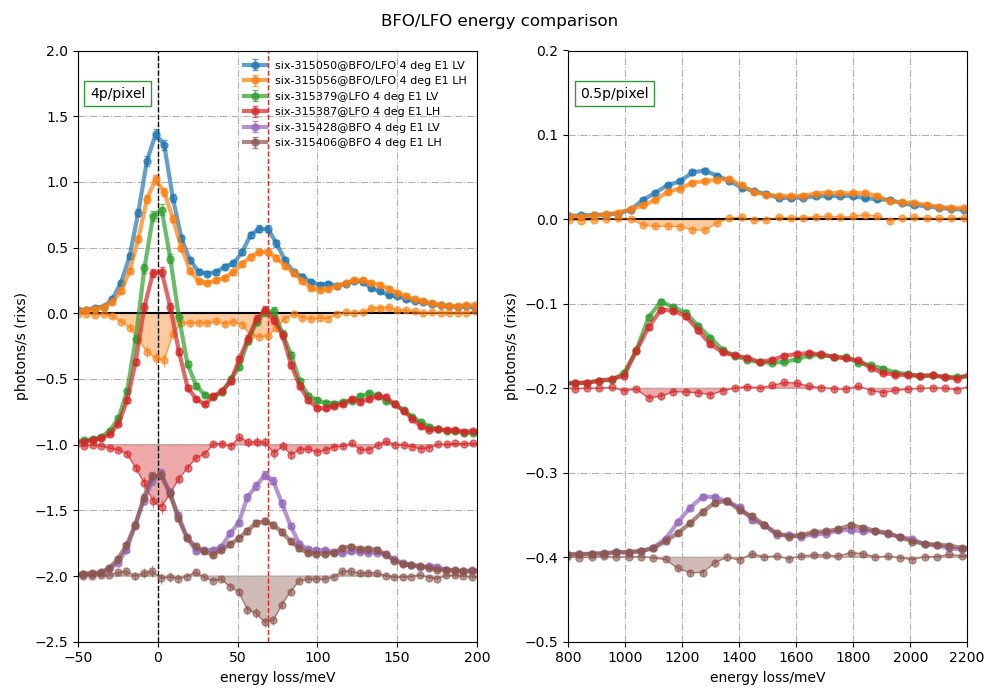

In [248]:
ppp = [4, 0.5]
######################################################

data = [
    #      th = 4 deg          ,      th = 20 deg          ,      th = 81 deg          ,      th = 90 deg          ,
    # E1  ,  E2  ,  E3  ,  E4  ,  E1  ,  E2  ,  E3  ,  E4  ,  E1  ,  E2  ,  E3  ,  E4  ,  E1  ,  E2  ,  E3  ,  E4  ,  
    315050,315062,315074,315089,314993,315006,315021,315103,315119,     1,     1,     1,315132,315148,315164,315180, # LV, BFO/LFO/STO
    315056,315068,315080,315095,314999,315014,315027,315109,315125,     1,     1,     1,315140,315156,315172,315188, # LH, BFO/LFO/STO
    315379,315331,     1,     1,315199,315235,     1,     1,     1,     1,     1,     1,315246,315254,     1,     1, # LV, LFO/STO
    315387,315337,     1,     1,315205,315239,     1,     1,     1,     1,     1,     1,315250,315258,     1,     1, # LH, LFO/STO
    315428,315411,     1,     1,315213,315226,     1,     1,     1,     1,     1,     1,315262,315359,     1,     1, # LV, BFO/STO
    315406,315419,     1,     1,315219,315230,     1,     1,     1,     1,     1,     1,315266,315367,     1,     1, # LH, BFO/STO
]
choice =  [
    #      th = 4 deg          ,      th = 20 deg          ,      th = 81 deg          ,      th = 90 deg          ,
    # E1  ,  E2  ,  E3  ,  E4  ,  E1  ,  E2  ,  E3  ,  E4  ,  E1  ,  E2  ,  E3  ,  E4  ,  E1  ,  E2  ,  E3  ,  E4  ,  
         1,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0, # LV, BFO/LFO/STO
         1,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0, # LH, BFO/LFO/STO
         1,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0, # LV, LFO/STO
         1,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0, # LH, LFO/STO
         1,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0, # LV, BFO/STO
         1,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0, # LH, BFO/STO
]
idx = [i for i,j in enumerate(choice) if j==1]
# idx = np.array(idx).reshape(2,int(len(idx)/2)).T.reshape(-1)
scan = [data[i] for i in idx]
xshifts = [[0 for i in range(len(idx))],[0 for i in range(len(idx))]]
yoff1, yoff2 = -1, -0.2
yshifts = [np.array([[i*yoff1,i*yoff1] for i in range(int(len(idx)/2))]).reshape(-1), np.array([[i*yoff2,i*yoff2] for i in range(int(len(idx)/2))]).reshape(-1)]
# yshifts = [[0,0,-1,-1,-2,-2,-3,-3],[0,0,-0.1,-0.1,-0.2,-0.2,-0.3,-0.3]]
title = 'BFO/LFO energy comparison'
labels = []
for i in idx:
    if int(i/32)==0:
        sam ='BFO/LFO '
    elif int(i/32)==1:
        sam = 'LFO '
    else:
        sam = 'BFO '
    if i%16<4:
        theta = 4
    elif i%16<8:
        theta = 20
    elif i%16<12:
        theta = 81
    else:
        theta = 90
        
    energy = 'E'+str(i%4+1)
    if int(i/16)%2==0:
        pol = 'LV'
    else:
        pol = 'LH'
    tmp = sam+str(theta)+' deg '+energy+' '+pol
    labels.append(tmp)

norm = 0
norm_range = [30,90] # meV, energy range for normalization
#################################################################
sig = 'rixs'
vari='th'
if sig == 'rixs':
    sig_x = 'E'
    sig_path = 'comb'
elif sig == 'rixs_l':
    sig_x = 'E_l'
    sig_path = 'left'
elif sig == 'rixs_r':
    sig_x = 'E_r'
    sig_path = 'right'

#################################################################
colors = ['C'+str(i) for i in range(len(scan))]
#################################################################
plt.close('all')
fig, axs = plt.subplots(1,2,figsize=(10,7))

for k, p in enumerate(ppp):
    points_per_pixel = p
    data_folder =getcwd()+'/Data/points_per_pixel-'+str(points_per_pixel)+'/'
    ax = axs[k]
    xshift = xshifts[k]
    yshift = yshifts[k]
    for i,n in enumerate(scan):
        if sample is None:
            sample='six'
        ####################################################################
        list_of_files = globf(data_folder + sample+'-' + str(n) + '*.hdf')
        latest_file = max(list_of_files, key=os_path.getctime)
        data_file = h5_file(latest_file, 'r')
        print(latest_file)
        count_time = np.sum(data_file['meta']['count_time'][:,0])
        vari_data = data_file['meta'][vari][0,0]
        print(vari_data)
        ####################################################################
        if len(list(data_file.keys())) == 3:
            if sig_path == 'comb':
                x = data_file['data']['E'][:, 0]+xshift[i]
                y = data_file['data']['rixs'][:, 0]
            else:
                x = data_file['data'][sig_path]['E'][:, 0]+xshift[i]
                y = data_file['data'][sig_path]['rixs'][:, 0]
    
        elif len(list(data_file.keys())) == 2:
            x = data_file['data'][sig_x][:, 0]+xshift[i]
            y = data_file['data'][sig][:, 0]
        else:
            print('Data structure is wrong, please process the data again!!!')
                        
        ##############################################################################
        if i%2==0:
            x_ref = x
            if norm==1:
                y_ref = y/np.sum(y[(x_ref>=norm_range[0])&(x_ref<=norm_range[1])])
            else:
                y_ref = y
        y_interp = np.interp(x_ref,x,y)
        y_interp_error = np.sqrt(y_interp / points_per_pixel * count_time)*points_per_pixel/count_time
        
        ##########################################
        if norm==1:
            norm_f = np.sum(y_interp[(x_ref>=norm_range[0])&(x_ref<=norm_range[1])])
        else:
            norm_f = 1
        ##########################################
        y_interp_norm = y_interp/norm_f
        y_interp_error_norm = y_interp_error/norm_f
        if i%2==0:
            y_ref_interp_error_norm = y_interp_error_norm
        ##########################################
        ax.errorbar(x_ref,y_interp_norm+yshift[i],yerr=y_interp_error_norm,
                     marker='o',mfc=colors[i],mec=colors[i],ecolor=colors[i],markersize=5,markeredgewidth=1,
                     linestyle='-',color=colors[i],lw=3.0,alpha=0.7,elinewidth=1,capsize=2.,
                    label='six-{:.0f}'.format(n)+'@'+labels[i])
        if i%2==1:
            ax.errorbar(x_ref,(y_interp_norm-y_ref)+yshift[i],yerr=np.sqrt(y_interp_error_norm**2+y_ref_interp_error_norm**2),
                        linestyle='-',lw=0.8,color=colors[i],alpha=0.6,marker='o',mfc=colors[i],mec=colors[i],ecolor=colors[i],markersize=5,markeredgewidth=1)
            ax.fill_between(x_ref,yshift[i],(y_interp_norm - y_ref)+yshift[i],color=colors[i],alpha=0.4)
    
    
    ax.axvline(0,linestyle='--',color='k',linewidth=1)
    ax.axvline(69,linestyle='--',color='C3',linewidth=1)
    ax.axhline(0,linestyle='-',color='k')
    #################################################################
    if k==0:
        ax.set_xlim(-50,200)
        ax.set_ylim(-0.5+yshift[-1],2)
    else:
        ax.set_xlim(800,2200)
        ax.set_ylim(-0.1+yshift[-1],0.2)
    ax.set_xlabel('energy loss/meV')
    
    
    # ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  
    
    if norm == 0:
        ax.set_ylabel('photons/s ('+sig+')')
    else:
        ax.set_ylabel('normalized intensity/arbi. ('+sig+')')
    #################################################################
    ax.grid(linestyle='-.')
    
    ax.text(.03, .92, str(points_per_pixel)+'p/pixel', transform=ax.transAxes,# ha="left", va="center",
           bbox=dict(edgecolor='green', facecolor='w',alpha=0.8))
    # ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))    
    #################################################################
    if k==0:
        ax.legend(fontsize=8,frameon=False,loc=1)
    
fig.suptitle(title)
fig.tight_layout()

In [1182]:
750/600

1.25

# Compress all Data files in current working folder

In [1051]:
# # Compress all data files in current working folder so that you can download it into local computer. 
# data_folder = getcwd() # Data folder where the data will be compressed


# project_name = 'Test'




# #################################################################
# #################################################################
# chdir(data_folder)
# !tar chvfz {project_name}.tar.gz * # Compressed file: tar.gz
# # !tar chvf {project_name}.tar * # Compressed file: tar
# #################################################################
# #################################################################
# print('**********************************************************************')
# print('**********************************************************************')
# print('**********************************************************************')
# print('All files have been successfully compressed into the file: '
#       +project_name+'.tar.gz '+'in folder: '+data_folder+'/!!!')
# print('**********************************************************************')
# print('**********************************************************************')